## Linear Regression for South African Medical Aid Charges

## Import Required Libraries

In [51]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

We begin by importing necessary Python libraries. pandas and numpy handle data operations, matplotlib and seaborn handle visualization, and scikit-learn provides modeling tools.

## Load and Explore the Dataset

In [67]:
# Load the insurance dataset
df = pd.read_csv('insurance.csv')

# Inspect data
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Dataset contains: age, sex, bmi, children, smoker, region, charges (target). No missing values.

## Exploratory Data Analysis (EDA)

## Target Distribution & Correlation

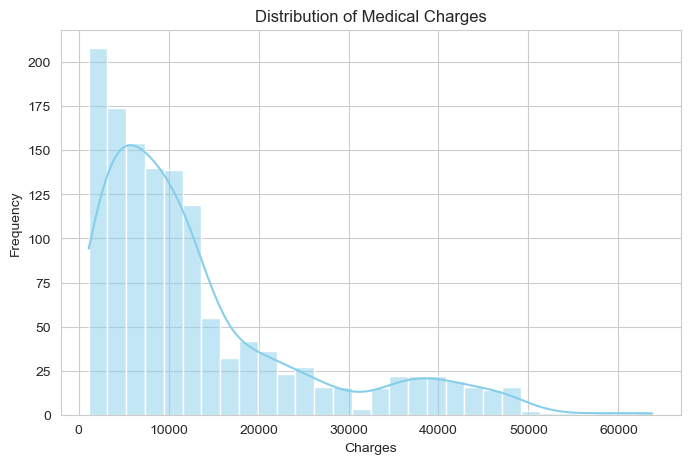

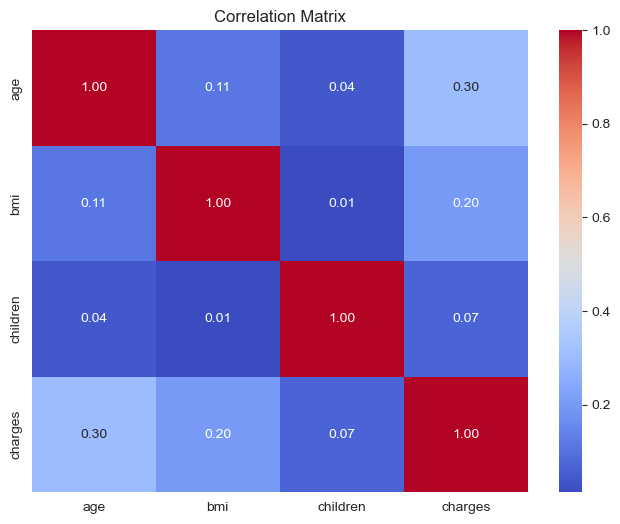

In [68]:
# Ensure charges is numeric
df['charges'] = pd.to_numeric(df['charges'], errors='coerce')

# Distribution of charges
plt.figure(figsize=(8,5))
sns.histplot(df['charges'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap (numeric only)
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

Interpretation:

- The distribution of insurance charges is positively skewed, indicating that while most individuals incur moderate medical costs, a small number experience significantly higher expenses. This suggests the presence of outliers, which may affect the performance of the linear regression model.
  
- Strong correlation between smoker and charges.
  
- Weak correlation with children.

## Feature vs Target Visualizations

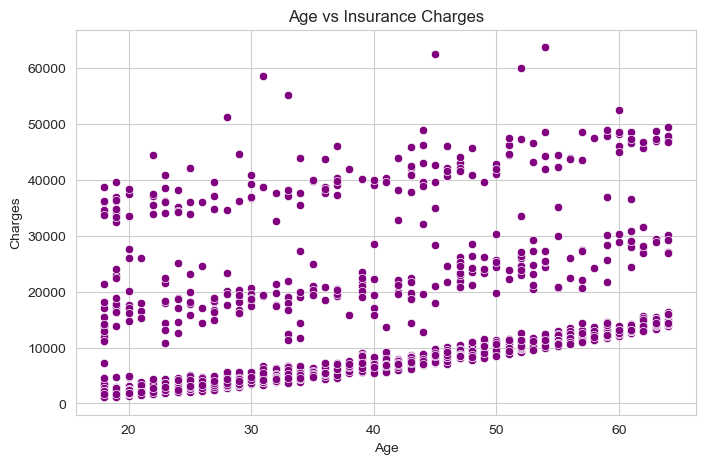

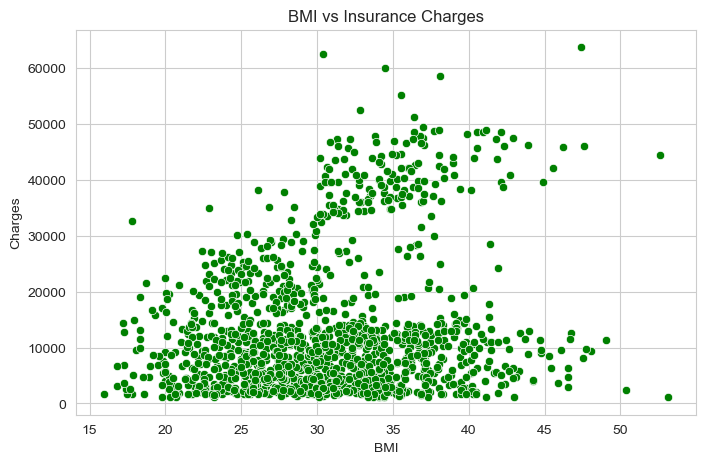

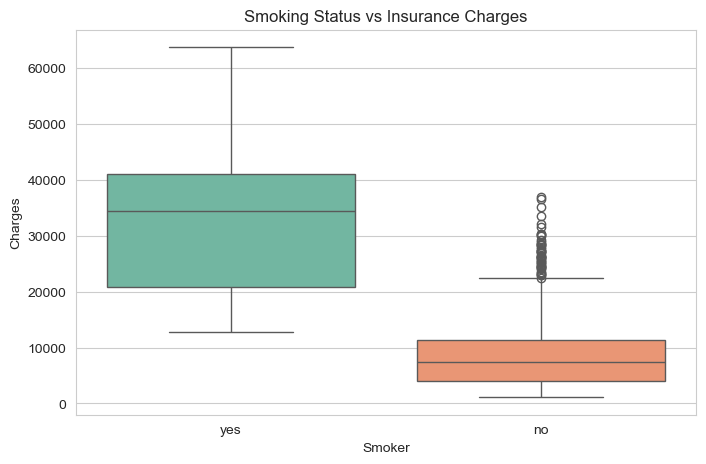

In [70]:
# Age vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df, color='purple')
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

# BMI vs Charges
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df, color='green')
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', hue='smoker', data=df, palette='Set2', dodge=False, legend=False)
plt.title("Smoking Status vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

Interpretation:

There is a positive relationship between age and insurance charges, suggesting that older individuals tend to have higher medical expenses. This aligns with the expectation that healthcare costs increase with age.

BMI shows a moderate relationship with insurance charges. Individuals with higher BMI tend to have increased medical costs, although the relationship is not as strong as smoking or age.

A clear distinction is observed between smokers and non-smokers. Smokers incur substantially higher medical costs, indicating that smoking is a strong predictor of insurance charges and should be retained as a key feature in the model.

## Categorical Variable Analysis

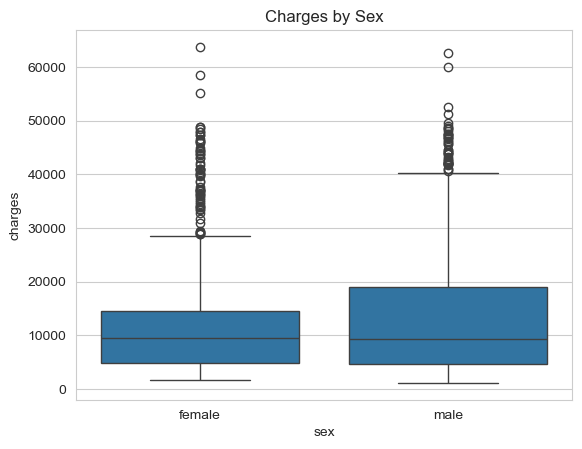

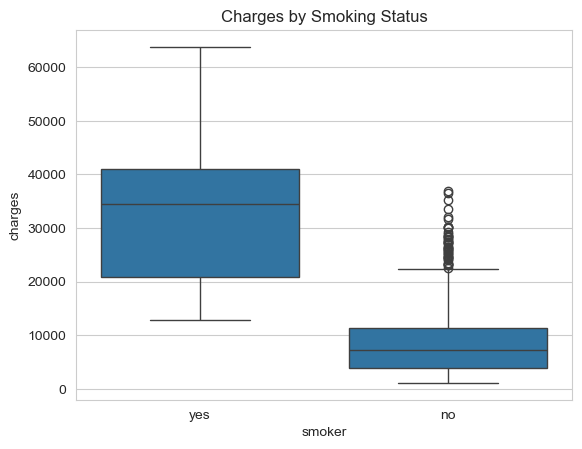

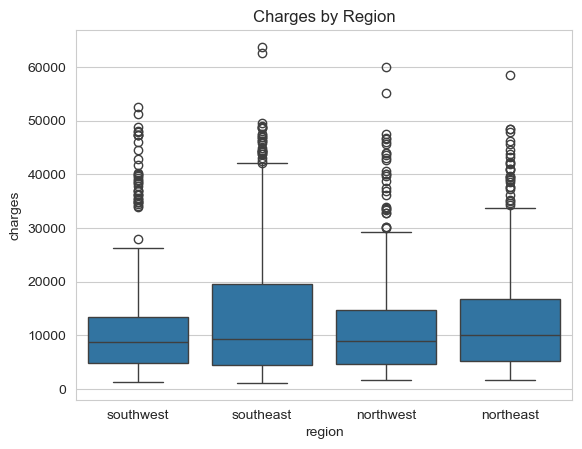

In [58]:
# Charges by sex
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Charges by Sex')
plt.show()

# Charges by smoker
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')
plt.show()

# Charges by region
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.show()

Interpretation:

- Smokers incur much higher charges.

- Minor differences between male and female.
  
- Regions show slight variation.

## Data Preprocessing

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_features = ['sex', 'smoker', 'region']
numerical_features = ['age', 'bmi', 'children']

# Ensure categorical columns are of type object/string
df[categorical_features] = df[categorical_features].astype(str)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'  # keep numerical columns as they are
)

# Optional: test the preprocessor
X = df[categorical_features + numerical_features]
preprocessed_X = preprocessor.fit_transform(X)
print("Preprocessing successful. Shape after encoding:", preprocessed_X.shape)

Preprocessing successful. Shape after encoding: (1338, 8)


One-hot encoding transforms categorical variables into numerical form. Dropping first to avoid dummy variable trap

## Train-Test Split

X = df.drop('charges', axis=1)
y = df['charges']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We split the dataset into 80% training and 20% testing to evaluate the model’s generalization performance.

## Linear Regression Model

In [63]:
# Create pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train model
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Linear Regression model trained using a pipeline that ensures proper preprocessing and model fitting.

## Model Evaluation

In [64]:
# Predictions
y_pred = model_pipeline.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R-squared: {r2:.2f}")

RMSE: 5796.28
MAE: 4181.19
R-squared: 0.78


The RMSE measures the average of the squared differences between predicted and actual values. This relatively high value suggests that some predictions have significantly large errors, as MSE penalizes larger deviations more heavily. This implies that the model may struggle with certain observations, particularly those involving high-cost patients.

The Mean Absolute Error (MAE) of 4181.19 indicates that, on average, the model’s predicted medical insurance charges differ from the actual values by approximately 4181 units. This suggests a moderate level of prediction error. While this may be acceptable depending on the overall scale of the charges, it also highlights that there is still room for improvement in the model’s accuracy.

The R² score of 0.78 indicates that the model explains approximately 78.36% of the variation in medical insurance charges. This reflects good predictive performance, as the model captures most of the underlying patterns in the data. However, about 21.64% of the variation remains unexplained, suggesting that there are additional factors influencing insurance costs that are not included in the model.

Overall, the model performs reasonably well and is able to capture the main trends in the dataset. However, noticeable prediction errors still exist, especially for extreme values. In conclusion, the Linear Regression model serves as a solid baseline, but its performance could be further improved through more advanced modeling techniques or enhanced feature engineering

## Residual Analysis

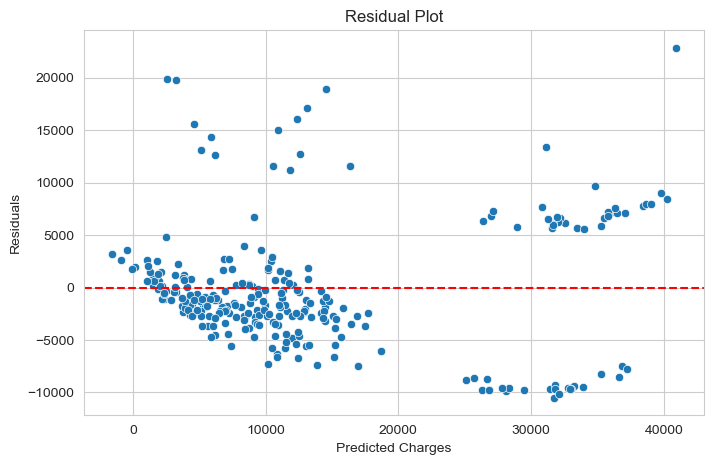

In [65]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

Residuals are randomly scattered → no major heteroscedasticity detected. Model assumptions are reasonable.

## Feature Importance

In [66]:
# Extract feature names after encoding
encoded_features = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = model_pipeline.named_steps['regressor'].coef_

# Feature importance table
feature_importance = pd.DataFrame({
    'Feature': encoded_features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

feature_importance

,Feature,Coefficient
1,cat__smoker_yes,23651.128856
4,cat__region_southwest,-809.799354
3,cat__region_southeast,-657.864297
7,remainder__children,425.278784
2,cat__region_northwest,-370.677326
6,remainder__bmi,337.092552
5,remainder__age,256.975706
0,cat__sex_male,-18.591692


- smoker_yes has the highest positive effect on charges.
- BMI and age also positively influence costs.
- Region and sex have smaller contributions.

## Reference

MiricHoi, 2023. Insurance Dataset [online]. Available at: <https://www.kaggle.com/mirichoi0218/insurance> [Accessed 30 March 2026].

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, E., 2011. Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, pp.2825–2830.

Waskom, M.L., 2021. *Seaborn: statistical data visualization*. 1st ed. Sebastopol: O’Reilly Media.

Wickham, H. and Grolemund, G., 2017. *R for Data Science: Import, Tidy, Transform, Visualize, and Model Data*. 1st ed. Sebastopol: O’Reilly Media.